In [ ]:
from google.colab import drive

print("Mounting Google Drive...")
drive.mount('/content/drive')

Mounting Google Drive...
Mounted at /content/drive


# Unzip tất cả KeyFrame vào /content

In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/HCMC AI Challenge 2026/combined_raw_keyframes.zip'
extract_dir = '/content'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Successfully unzipped '{zip_file_path}' to '{extract_dir}'")

Successfully unzipped '/content/drive/MyDrive/HCMC AI Challenge 2026/combined_raw_keyframes.zip' to '/content'


# Trả về lưới ảnh theo list ảnh

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import math # For calculating grid dimensions

def get_folder_name(image_id):
    """
    Derives the subfolder name from the image_id based on the pattern:
    'LXX_vYYY_...' -> 'LXX_VYYY'
    """
    parts = image_id.split('_')
    if len(parts) >= 2:
        prefix = parts[0]
        version = parts[1]
        # Capitalize 'v' if it's the first character of the version part
        if version.startswith('v') and len(version) > 1:
            version = 'V' + version[1:]
        return f"{prefix}_{version}"
    return "" # Return empty string if the pattern doesn't match

In [ ]:
def display_keyframes_grid(image_ids):
    """
    Displays a grid of keyframe images given a list of image IDs.

    Args:
        image_ids (list): A list of strings, where each string is an image ID
                          (e.g., 'L26_v118_transnetv2_0014_07').
    """
    if not image_ids:
        print("No image IDs provided to display.")
        return

    images_to_display = []
    titles = []
    base_dir = '/content/keyframes'

    for image_id in image_ids:
        folder_name = get_folder_name(image_id)
        if not folder_name:
            print(f"Could not determine folder name for image ID: {image_id}. Skipping.")
            continue

        image_path = os.path.join(base_dir, folder_name, f"{image_id}.jpg")

        if os.path.exists(image_path):
            try:
                img = mpimg.imread(image_path)
                images_to_display.append(img)
                titles.append(image_id)
            except Exception as e:
                print(f"Error loading image {image_path}: {e}. Skipping.")
        else:
            print(f"Image not found at: {image_path}. Skipping.")

    if not images_to_display:
        print("No images were successfully loaded for display.")
        return

    num_images = len(images_to_display)
    # Determine grid size: aim for a somewhat square layout, max 4 columns
    cols = min(num_images, 4)
    rows = math.ceil(num_images / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = axes.flatten() # Flatten in case of single row/column for easier iteration

    for i, img in enumerate(images_to_display):
        axes[i].imshow(img)
        axes[i].set_title(titles[i], fontsize=10)
        axes[i].axis('off') # Hide axes ticks and labels

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [ ]:
# Example Usage:
# Replace with your actual list of image IDs
# image_list = ['L26_v118_transnetv2_0014_07']
# display_keyframes_grid(image_list)

# You can add more image IDs to the list to display multiple images:
image_list_multi = [
    'L26_v118_transnetv2_0014_07',
    'L26_v118_transnetv2_0014_08',
    'L26_v118_transnetv2_0014_09',
    'L26_v118_transnetv2_0014_10',
    'L26_v118_transnetv2_0014_11',
    'L22_v001_transnetv2_0063_01',
    'L26_v159_transnetv2_0069_01',
    'L21_v030_transnetv2_0093_06',
]
print("\nDisplaying multiple images:")
display_keyframes_grid(image_list_multi)


Displaying multiple images:
Image not found at: /content/keyframes/L26_V118/L26_v118_transnetv2_0014_07.jpg. Skipping.
Image not found at: /content/keyframes/L26_V118/L26_v118_transnetv2_0014_08.jpg. Skipping.
Image not found at: /content/keyframes/L26_V118/L26_v118_transnetv2_0014_09.jpg. Skipping.
Image not found at: /content/keyframes/L26_V118/L26_v118_transnetv2_0014_10.jpg. Skipping.
Image not found at: /content/keyframes/L26_V118/L26_v118_transnetv2_0014_11.jpg. Skipping.
Image not found at: /content/keyframes/L22_V001/L22_v001_transnetv2_0063_01.jpg. Skipping.
Image not found at: /content/keyframes/L26_V159/L26_v159_transnetv2_0069_01.jpg. Skipping.
Image not found at: /content/keyframes/L21_V030/L21_v030_transnetv2_0093_06.jpg. Skipping.
No images were successfully loaded for display.


## Setup for Multi-modal Search with SigLIP and OpenCLIP

In [ ]:
# Install necessary libraries
!pip install transformers sentence-transformers faiss-cpu torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 12.9 MB/s eta 0:00:00


In [ ]:
import torch
import faiss
from transformers import AutoProcessor, AutoModel
from sentence_transformers import SentenceTransformer
import numpy as np
import os

# --- Load SigLIP2 Model and Processor ---
siglip2_model_name = "google/siglip2-base-patch16-naflex"
print(f"Loading SigLIP2 model: {siglip2_model_name}...")
siglip2_processor = AutoProcessor.from_pretrained(siglip2_model_name)
siglip2_model = AutoModel.from_pretrained(siglip2_model_name).to('cuda' if torch.cuda.is_available() else 'cpu')
print("SigLIP2 model loaded.")

# --- Load OpenCLIP (ViT-B-32) Model ---
# Using SentenceTransformer for easy access to CLIP models
openclip_model_name = "clip-ViT-B-32" # Corrected model name
print(f"Loading OpenCLIP model: {openclip_model_name}...")
openclip_model = SentenceTransformer(openclip_model_name).to('cuda' if torch.cuda.is_available() else 'cpu')
print("OpenCLIP model loaded.")

Loading SigLIP2 model: google/siglip2-base-patch16-naflex...


preprocessor_config.json:   0%|          | 0.00/393 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/329 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/40.2k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

OpenCLIP model loaded.


In [ ]:
# --- Load FAISS Indexes ---
faiss_base_path = '/content/drive/MyDrive/HCMC AI Challenge 2026/'

faiss_siglip2_path = os.path.join(faiss_base_path, 'faiss_siglip2.bin')
faiss_openclip_path = os.path.join(faiss_base_path, 'faiss_openclip.bin')

print(f"Loading FAISS SigLIP2 index from: {faiss_siglip2_path}...")
try:
    index_siglip2 = faiss.read_index(faiss_siglip2_path)
    print(f"SigLIP2 index loaded. Total vectors: {index_siglip2.ntotal}")
except Exception as e:
    print(f"Error loading SigLIP2 FAISS index: {e}")
    index_siglip2 = None

print(f"Loading FAISS OpenCLIP index from: {faiss_openclip_path}...")
try:
    index_openclip = faiss.read_index(faiss_openclip_path)
    print(f"OpenCLIP index loaded. Total vectors: {index_openclip.ntotal}")
except Exception as e:
    print(f"Error loading OpenCLIP FAISS index: {e}")
    index_openclip = None

Loading FAISS SigLIP2 index from: /content/drive/MyDrive/HCMC AI Challenge 2026/faiss_siglip2.bin...
SigLIP2 index loaded. Total vectors: 337351
Loading FAISS OpenCLIP index from: /content/drive/MyDrive/HCMC AI Challenge 2026/faiss_openclip.bin...
OpenCLIP index loaded. Total vectors: 337351


### Embedding Functions

In [ ]:
def embed_siglip2(text_query):
    """Embeds a text query using the SigLIP2 model."""
    if siglip2_model is None:
        print("SigLIP2 model not loaded.")
        return None
    inputs = siglip2_processor(text=text_query, return_tensors="pt").to(siglip2_model.device)
    text_inputs = {k: v for k, v in inputs.items() if k in ['input_ids', 'attention_mask']}
    with torch.no_grad():
        # Access the text_model component and get its pooled output
        text_encoder_output = siglip2_model.text_model(**text_inputs)
        text_features = text_encoder_output.pooler_output
    return text_features.cpu().numpy().astype('float32')

def embed_openclip(text_query):
    """Embeds a text query using the OpenCLIP (SentenceTransformer) model."""
    if openclip_model is None:
        print("OpenCLIP model not loaded.")
        return None
    return openclip_model.encode(text_query, convert_to_numpy=True).astype('float32')

### Reciprocal Rank Fusion (RRF) Function

In [ ]:
def reciprocal_rank_fusion(results_lists, k=60):
    """
    Performs Reciprocal Rank Fusion (RRF) to combine multiple ranked lists.

    Args:
        results_lists (list of lists of str/int): Each inner list is a ranked list of item IDs.
        k (int): Parameter for RRF, higher k means lower ranks contribute more.

    Returns:
        list: A single ranked list of unique item IDs based on RRF scores.
    """
    fused_scores = {}

    for results_list in results_lists:
        for rank, item_id in enumerate(results_list):
            # Rank is 1-based for RRF formula
            score = 1.0 / (k + rank + 1)
            fused_scores[item_id] = fused_scores.get(item_id, 0.0) + score

    # Sort items by their fused scores in descending order
    sorted_items = sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    return [item for item, score in sorted_items]

### Multi-modal Search Function

In [ ]:
def perform_multimodal_search(query_text, num_results=10):
    """
    Performs a multi-modal search using SigLIP2 and OpenCLIP embeddings and FAISS indexes,
    then combines results using RRF.

    Args:
        query_text (str): The text query to search for.
        num_results (int): The number of top results to retrieve from each FAISS index.

    Returns:
        list: A ranked list of item IDs (from FAISS search) fused by RRF.
    """
    print(f"Processing query: '{query_text}'")
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # 1. Embed the query
    vec1 = embed_siglip2(query_text)
    vec2 = embed_openclip(query_text)

    if vec1 is None or vec2 is None:
        print("Failed to generate one or both embeddings. Aborting search.")
        return []

    # Reshape vec1 and vec2 to be 2D arrays (1, embedding_dimension) as required by FAISS search
    vec1 = vec1.reshape(1, -1)
    vec2 = vec2.reshape(1, -1)

    # 2. Search FAISS indexes
    results_siglip2 = []
    if index_siglip2:
        print(f"Searching SigLIP2 index for top {num_results} results...")
        D1, I1 = index_siglip2.search(vec1, num_results)  # D: distances, I: indices
        results_siglip2 = [str(idx) for idx in I1[0] if idx != -1] # Convert to string IDs and filter -1 (not found)
        print(f"SigLIP2 found {len(results_siglip2)} results.")
    else:
        print("SigLIP2 index not available.")

    results_openclip = []
    if index_openclip:
        print(f"Searching OpenCLIP index for top {num_results} results...")
        D2, I2 = index_openclip.search(vec2, num_results)
        results_openclip = [str(idx) for idx in I2[0] if idx != -1] # Convert to string IDs and filter -1 (not found)
        print(f"OpenCLIP found {len(results_openclip)} results.")
    else:
        print("OpenCLIP index not available.")

    # 3. Combine results using RRF
    if not results_siglip2 and not results_openclip:
        print("No results from any index.")
        return []

    all_results_lists = []
    if results_siglip2: all_results_lists.append(results_siglip2)
    if results_openclip: all_results_lists.append(results_openclip)

    if all_results_lists:
        print("Applying Reciprocal Rank Fusion...")
        fused_results = reciprocal_rank_fusion(all_results_lists)
        print(f"RRF produced {len(fused_results)} fused results.")
        return fused_results
    else:
        return []

# Example usage:
query = '''
(two women and one man) sitting side-by-side, focused on playing Handpan. One person wearing a white shirt is seated between two others wearing black shirts. The background features a multi-compartment bookshelf filled with colorful books.
'''
fused_search_results = perform_multimodal_search(query)
print("\nFused Search Results (Top 5):", fused_search_results[:5])

Processing query: '
(two women and one man) sitting side-by-side, focused on playing Handpan. One person wearing a white shirt is seated between two others wearing black shirts. The background features a multi-compartment bookshelf filled with colorful books.
'
Searching SigLIP2 index for top 10 results...
SigLIP2 found 10 results.
Searching OpenCLIP index for top 10 results...
OpenCLIP found 10 results.
Applying Reciprocal Rank Fusion...
RRF produced 20 fused results.

Fused Search Results (Top 5): ['326461', '329404', '326459', '305498', '326460']


Retrieved 20 keyframe IDs from the database.
First 5 retrieved keyframe IDs: ['L21_V016_transnetv2_0140_00', 'L27_V015_transnetv2_0124_04', 'L27_V016_transnetv2_0055_01', 'L28_V005_transnetv2_0108_03', 'L28_V006_transnetv2_0148_01']

Displaying retrieved keyframes:


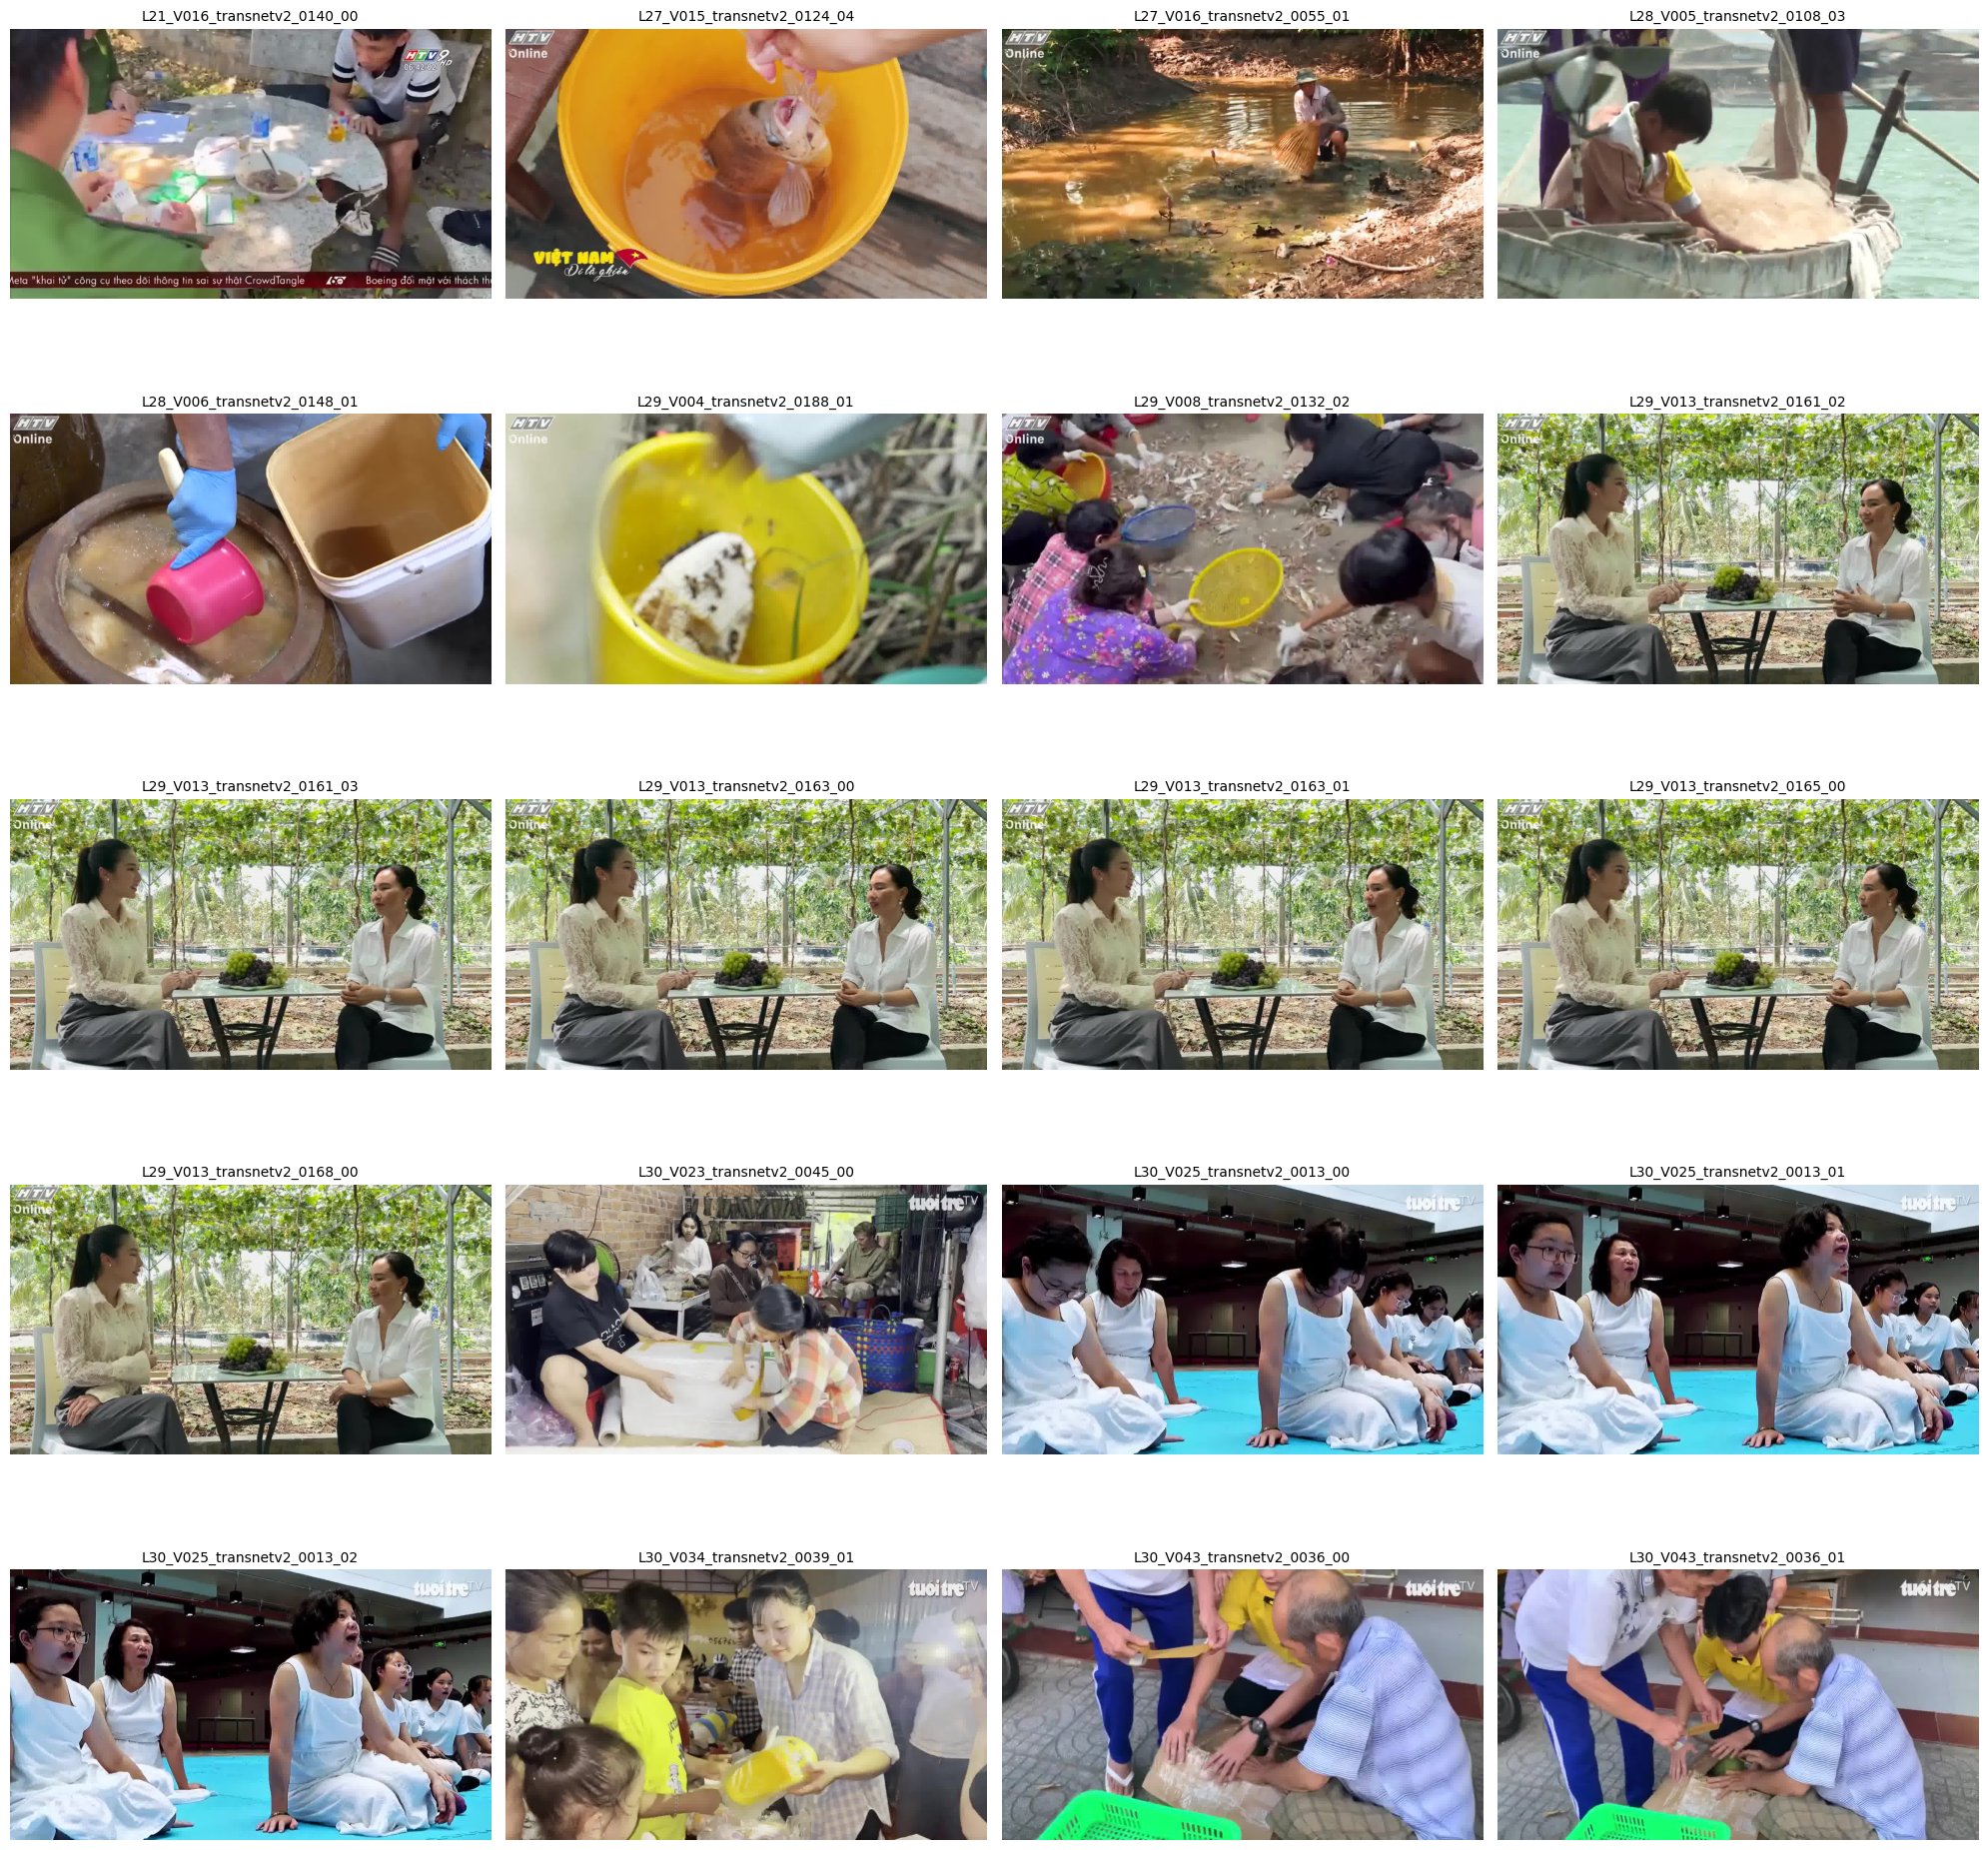

In [ ]:
import sqlite3

metadata_db_path = os.path.join(faiss_base_path, 'metadata.db')

def get_keyframe_ids_from_global_ids(global_ids):
    """
    Retrieves keyframe_ids from metadata.db given a list of global_ids.

    Args:
        global_ids (list): A list of global_ids (strings) to look up.

    Returns:
        list: A list of corresponding keyframe_ids.
    """
    conn = None
    keyframe_ids = []
    try:
        conn = sqlite3.connect(metadata_db_path)
        cursor = conn.cursor()

        # Prepare placeholders for the IN clause
        placeholders = ','.join(['?' for _ in global_ids])
        query = f"SELECT keyframe_id FROM keyframes WHERE global_id IN ({placeholders})"

        cursor.execute(query, global_ids)
        results = cursor.fetchall()
        keyframe_ids = [row[0] for row in results]

    except sqlite3.Error as e:
        print(f"Database error: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")
    finally:
        if conn:
            conn.close()
    return keyframe_ids

# Assuming fused_search_results contains the global_ids as strings
# from the previous step
retrieved_keyframe_ids = get_keyframe_ids_from_global_ids(fused_search_results)

print(f"Retrieved {len(retrieved_keyframe_ids)} keyframe IDs from the database.")
print("First 5 retrieved keyframe IDs:", retrieved_keyframe_ids[:5])

# Display the retrieved keyframes
if retrieved_keyframe_ids:
    print("\nDisplaying retrieved keyframes:")
    display_keyframes_grid(retrieved_keyframe_ids)
else:
    print("No keyframes to display.")

### The clip we're looking for shows two women feeding goats: one wearing a white t-shirt with a red shawl draped over her shoulders, the other a traditional purple striped long-sleeved shirt. Both are smiling, appearing to be enjoying themselves.

### The spacious farm, with its corrugated iron roof and wooden fence, is divided into several rows of pens, including long lines of goats being kept inside.

### The clip we're looking for begins with a chef arranging vegetarian spring rolls on a plate. The filling consists of rolled green vegetables and tofu, wrapped in yellow and purple rice paper. The plate is decorated with green leaves and purple-yellow pansies, creating a refreshing and delicate feel.

### This video is of the world's largest Japanese food festival. Find the exact scene where a little girl is wearing a red octopus/squid on her chest. She is holding a paper bag in her hand.

### The clip shows a young man wearing a black baseball cap and a white T-shirt with English lettering, sitting next to a box. On the box, he has arranged many randomly shaped pieces of cardboard.

### Thanks to the light shining from one side, the pieces of cardboard cast shadows on the wall, forming a portrait of a man with a clear face, neatly styled hair, and wearing a suit.
---------------
### Đây là phần giới thiệu việc phóng tàu vũ trụ tư nhân. Đoạn clip bắt đầu với hình ảnh 4 phi hành gia mặc áo đen. Một trong những nhiệm vụ dự kiến của tàu vũ trụ là nghiên cứu ánh sáng cực quang ở vùng cực

### This is an introduction to the launch of a private spacecraft. The clip begins with footage of four astronauts wearing black suits. One of the spacecraft's planned missions is to study auroras in the polar regions.

-----------------------
### Mẩu tin giới thiệu về đàn hổ tại một địa phương ở miền Nam vừa có thêm khoảng 3-6 con hổ con. Đây là một giống hổ quý hiếm

### A news report introduces a tiger population in a southern locality that has recently welcomed between three and six cubs. This is a rare tiger breed.
-----------------------
### Đoạn clip cần tìm là cảnh quay trong một khu rừng, dưới gốc cây to với nhiều lá khô phủ đầy mặt đất. Nổi bật ở cận cảnh là một chú chim có bộ lông đen ánh xanh ở đầu và thân trên, còn cánh và lưng màu nâu đỏ. Đôi mắt chim đỏ rực, tạo điểm nhấn rõ ràng. Đây là loài chim thường thấy ở vùng Nam Bộ Việt Nam.

### The clip in question features a scene in a forest, set at the base of a large tree where the ground is carpeted with dry leaves. A prominent close-up shows a bird with plumage that is black with a greenish sheen on its head and upper body, while its wings and back are reddish-brown. Its eyes are a striking, vivid red. This species is commonly found in Southern Vietnam.
-----------------------
### Đoạn clip là cảnh thu hoạch dứa ở miền Tây: một bà cụ ngồi bên giỏ dứa trò chuyện với cô gái mặc áo hồng quàng khăn rằn; xung quanh chất đầy dứa, phía sau có người phụ nữ đội nón lá cầm trái dứa và một chiếc ghe xanh đậu cạnh bờ, tạo không khí nông thôn mộc mạc, yên bình.

### The clip captures a pineapple harvest scene in the Mekong Delta: an elderly woman sits beside a basket of pineapples, chatting with a young woman wearing a pink shirt and a traditional checkered scarf; the area is piled high with pineapples, while in the background, a woman wearing a conical hat holds a pineapple, and a green boat is moored by the bank, creating a rustic, peaceful rural atmosphere.
-----------------------
### Tìm chính xác đoạn clip ngắn có ba người (hai phụ nữ và một nam giới) đang ngồi cạnh nhau, tập trung chơi nhạc cụ kim loại có dạng tròn, rỗng, với các vết lõm để tạo ra âm thanh khi gõ tay. Có 1 người mặc áo trắng ngồi giữa 2 người mặc áo đen. Bối cảnh phía sau là một kệ sách nhiều ngăn, xếp đầy sách với nhiều màu sắc

### Find the specific short clip featuring three people (two women and one man) sitting side-by-side, focused on playing a round, hollow metal instrument with indentations that produce sound when struck by hand. One person wearing a white shirt is seated between two others wearing black shirts. The background features a multi-compartment bookshelf filled with colorful books.
-----------------------
### Đoạn video mô tả cảnh trang trí bánh rán. Phân cảnh bắt đầu là một chiếc đĩa sứ màu trắng nằm trên một khay gỗ hình chữ nhật. Bên cạnh chiếc đĩa sứ là một chén đựng một vài trái dâu, nhưng có 2 trái bị rơi ra ngoài. Ngoài ra, bên cạnh đĩa sứ còn có một chén sứ nhỏ màu trắng đựng chuối đã được cắt sẵn và một cái thìa nhỏ màu nâu. Phân cảnh tiếp theo cho thấy đầu bếp đặt 2 chiếc bánh rán lên đĩa sứ và bắt đầu trang trí. Bước đầu tiên là việc rưới chocolate lên trên mặt bánh. Sau đó, đầu bếp đặt các lát chuối lên trên một chiếc bánh rán, chiếc còn lại được đặt các lát dâu tây lên.

### The video shows the process of decorating doughnuts. The scene opens with a white porcelain plate resting on a rectangular wooden tray. Beside the plate sits a bowl containing a few strawberries, with two of them having spilled out. Also next to the plate are a small white porcelain bowl of pre-cut banana slices and a small brown spoon. The next shot shows the chef placing two doughnuts onto the plate and beginning to decorate them. The first step involves drizzling chocolate over the tops of the doughnuts. Then, the chef arranges banana slices on one doughnut and strawberry slices on the other.
-----------------------
### Đoạn video mô tả một người ngồi vệ sinh máy ảnh. Công đoạn này bắt đầu bằng việc tháo rời máy ảnh. Tiếp theo, chiếc ống kính đã được tháo rời và được đặt ngay ngắn trên một chiếc khăn màu tím hồng. Phân cảnh cuối cùng là vệ sinh ống kính (lens) bằng một chiếc tăm bông.

### The video shows someone cleaning a camera. The process begins with disassembling the camera. Next, the detached lens is placed neatly on a purplish-pink cloth. The final shot shows the lens being cleaned with a cotton swab.
-----------------------
### Đoạn clip bắt đầu với cảnh một tác phẩm điêu khắc cát hoành tráng tại Lễ hội điêu khắc trên cát. Tác phẩm mô tả cảnh những thanh niên chơi thể thao đường phố: một người trượt patin, hai người trượt ván.Nền phía sau là họa tiết vòm cong lớn và có khắc chữ. Tiếp theo có cảnh nhiều tác phẩm khác bằng cát, và có 2 cột khói màu hồng

### The clip opens with a shot of a magnificent sand sculpture at the sand sculpture festival. The artwork depicts young people engaged in street sports: one inline skater and two skateboarders. In the background, there is a large arched design featuring carved lettering. The scene then shifts to show various other sand sculptures, accompanied by two plumes of pink smoke.
-----------------------
### Đoạn video về một chương trình từ thiện của một câu lạc bộ tên là FANA. Trong đoạn video có thể thấy câu lạc bộ này đang đi trao quà tại một xã thuộc tỉnh Khánh Hòa. Hỏi xã này có tên là gì? (tại thời điểm đó)

### This video features a charity program organized by a club named FANA. In the video, the club is shown distributing gifts in a commune within Khanh Hoa Province. What was the name of this commune at the time?
-----------------------
### Đoạn video trong buổi trao quà từ thiện diễn ra tại 1 bệnh viện trong dịp Xuân 2024. Trong cảnh có hai người đàn ông (mặc áo sơ mi hồng và sơ mi trắng) đứng hai bên, đại diện ban tổ chức. Ở giữa là bốn em nhỏ và thiếu niên, trong đó có em mặc áo đỏ, em mặc áo trắng, em mặc váy hồng và em mặc áo xanh. Các em được trao bảng tượng trưng với nội dung “Chương trình: Trao kinh phí hỗ trợ cho trẻ em mồ côi do dịch COVID-19”. Trước mặt mỗi em là túi quà lớn mang logo y tế. Phía sau là phông nền màu đỏ với khẩu hiệu đón xuân và thông tin sự kiện.

### This video captures a charity gift-giving event held at a hospital during the 2024 Spring season. Two men—one in a pink shirt and the other in a white shirt—stand on either side, representing the organizers. Between them are four children and youths, wearing a red shirt, a white shirt, a pink dress, and a blue shirt, respectively. They are being presented with a ceremonial placard reading "Program: Providing financial support for children orphaned by the COVID-19 pandemic." Large gift bags bearing a medical logo are placed in front of each child. In the background stands a red backdrop featuring a spring-themed slogan and event details.
-----------------------
### Trong đoạn video có 2 câu thơ của một nhà thơ ca ngợi anh hùng Nguyễn Trung Trực trong đình thần Nguyễn Trung Trực tại Kiên Giang. Hai câu thơ đó là gì?

### The video features two lines of poetry praising the hero Nguyen Trung Truc, found at the Nguyen Trung Truc Communal House in Kien Giang. What are those two lines?
-----------------------
### Trên đĩa tròn màu trắng có 1 ly panna cotta. Có một bàn tay lần lượt đặt thêm 2 ly panna cotta nữa vào đĩa.Mỗi ly panna cotta có lớp kem mịn màu trắng ngà, bên trên trang trí vài lát nho đỏ, thêm lá bạc hà xanh tạo điểm nhấn tươi mát. Bên cạnh trên đĩa còn có hai bông hoa ăn được (màu đỏ và vàng) để tăng phần đẹp mắt.

### A glass of panna cotta sits on a round white plate. A hand places two additional glasses of panna cotta onto the plate, one by one. Each glass features a smooth, ivory-white cream layer topped with a few slices of red grape and a fresh green mint leaf for a touch of vibrancy. Two edible flowers—one red and one yellow—also adorn the plate, adding to its visual appeal.
-----------------------
### Đoạn video vể nghiên cứu tại 1 Đại học ở thành phố Lausanne về việc nghiên cứu cơ chế bay của bọ để chế tạo robot

### A video about research conducted at a university in Lausanne into the flight mechanisms of beetles, aimed at developing robots.
-----------------------
### Đoạn video về một người phụ nữ dạy nấu ăn cho những người khác. Trong đoạn video có thể thấy một người đang cầm công thức món ăn với nguyên liệu chính là 200g thịt nạc xay. Hỏi tiêu đề của công thức nấu ăn (tên món ăn) này là gì?

### The video shows a woman teaching others how to cook. In the video, someone is holding a recipe that lists 200g of lean ground meat as the main ingredient. What is the title of this recipe (the name of the dish)?
-----------------------
### Đoạn clip về 1 thị trấn ven biển thu hút du khách hiếu kỳ nhờ 1 loài động vật biển nguy hiểm. Loài động vật này nổi tiếng trong 1 bộ phim của đạo diễn Steven Spielberg được sản xuất vào năm 1975

### A video clip featuring a coastal town has attracted curious tourists thanks to a dangerous marine animal. This creature is famous for its role in a 1975 film directed by Steven Spielberg.
-----------------------
### Đoạn video về tường thuật một cuộc đua xe đạp. Tìm phân cảnh với góc quay trực diện từ trên cao xuống dõi theo các tay đua. Trong khung hình gồm có 3 tay đua đang đạp thành một đường thẳng. Cả 3 tay đua đều đến từ cùng một đội, với đồng phục áo trắng quần vàng xanh. Tay đua đầu tiên đội nón trắng, tay đua thứ hai đội nón đỏ và tay đua cuối cùng đội nón đen.

### This video clip features coverage of a bicycle race. Look for a shot taken from a high, direct overhead angle that tracks the cyclists. The frame shows three cyclists riding in a single-file line. All three belong to the same team, wearing white jerseys and yellow-and-green shorts. The first cyclist wears a white helmet, the second a red helmet, and the last a black helmet.
-----------------------
### Tìm một đoạn video đua xe đạp, góc quay từ flycam trên cao, một vận động viên mặc áo xanh dương, trắng đang vượt ba vận động viên khác và lên vị trí dẫn đầu. Biết sau đó vận động viên này dẫn đầu suốt đoạn đường còn lại đến đích.

### Find a video of a bicycle race featuring an overhead drone shot where a cyclist wearing a blue and white jersey overtakes three other riders to take the lead, and subsequently holds that lead for the remainder of the race to the finish line.

In [ ]:
query_text = "Japanese food festival. Find the exact scene where a little girl is wearing a red octopus/squid on her chest. She is holding a paper bag in her hand."
fused_search_results = perform_multimodal_search(query_text)

print("\nFused Search Results (Top 5):", fused_search_results[:5])

retrieved_keyframe_ids = get_keyframe_ids_from_global_ids(fused_search_results)

print(f"Retrieved {len(retrieved_keyframe_ids)} keyframe IDs from the database.")
print("First 5 retrieved keyframe IDs:", retrieved_keyframe_ids[:5])

# Display the retrieved keyframes
if retrieved_keyframe_ids:
    print("\nDisplaying retrieved keyframes:")
    display_keyframes_grid(retrieved_keyframe_ids)
else:
    print("No keyframes to display.")